In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for your charts (looks better in reports)
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

# Load your data
df = pd.read_csv('Customer-Churn.csv')

In [11]:
# Convert TotalCharges to numeric, turning errors (spaces) into NaN, then drop them
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Drop CustomerID as it's just a random string
df.drop('customerID', axis=1, inplace=True)

# Convert the 'Churn' target into 0 and 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Data ready! Shape: {df.shape}")

Data ready! Shape: (7032, 20)


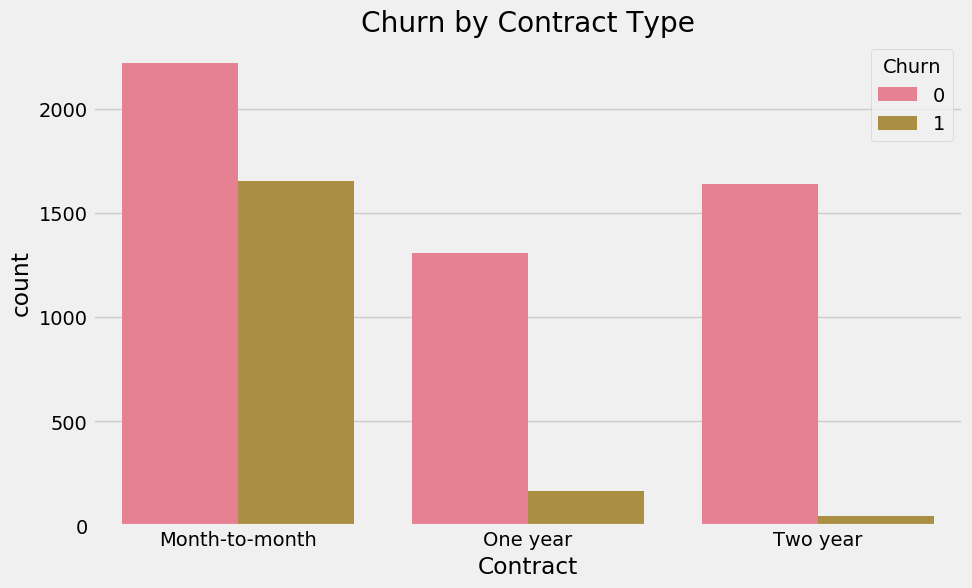

In [12]:
# Visualize how Contract type affects Churn
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

# Insight: You will see Month-to-month contracts have the highest churn.

In [13]:
# Convert all text columns into dummy variables
df_final = pd.get_dummies(df)

# Look at the new columns
print(df_final.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Female  \
0              0       1           29.85         29.85      0              1   
1              0      34           56.95       1889.50      0              0   
2              0       2           53.85        108.15      1              0   
3              0      45           42.30       1840.75      0              0   
4              0       2           70.70        151.65      1              1   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0            0           0            1              1  ...   
1            1           1            0              1  ...   
2            1           1            0              1  ...   
3            1           1            0              1  ...   
4            0           1            0              1  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                    0                        1                  0   


In [14]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Churn', axis=1) # Everything except the answer
y = df_final['Churn'] # The answer we want to predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

Training on 5625 rows, Testing on 1407 rows.


In [15]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Check results
print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy Score: 0.7704335465529495

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407



   ---------------------------------------- 462.1/462.1 kB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 2.5/2.5 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 23.2/23.2 MB 4.9 MB/s eta 0:00:00


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


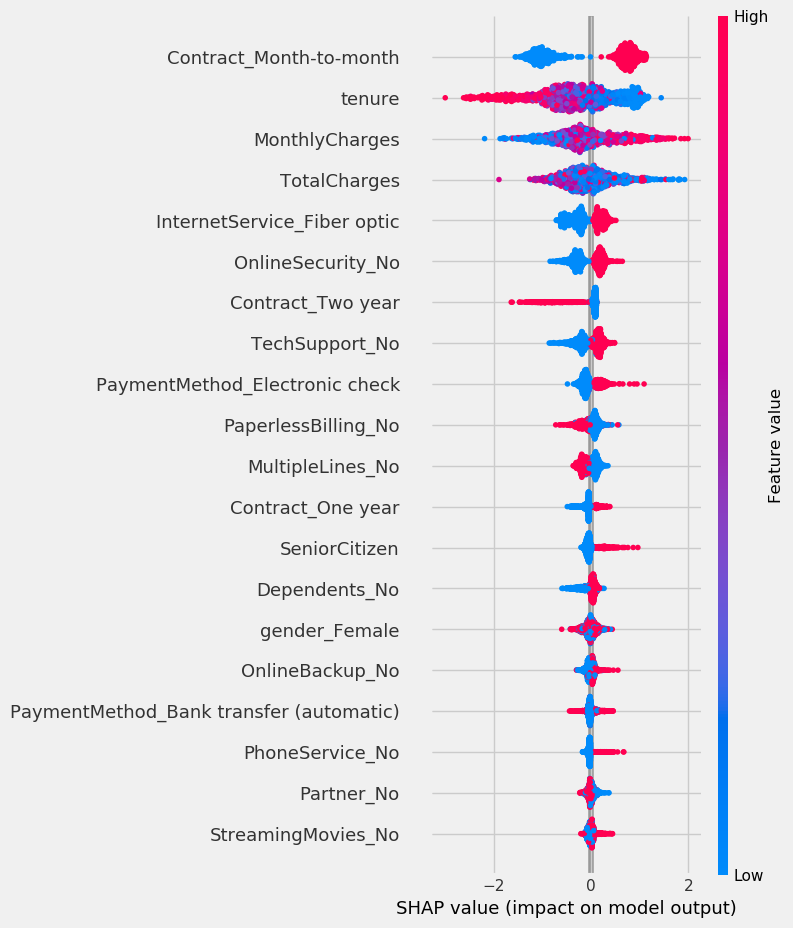

In [17]:
!pip install shap
import shap

# 1. Initialize the SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# 2. Create the Summary Plot
# This shows the top features and their impact direction
shap.summary_plot(shap_values, X_test)

In [18]:
!pip install joblib
import joblib

# Save the model and the columns (needed for the UI later)
joblib.dump(model, 'churn_model.pkl')
joblib.dump(X.columns, 'model_columns.pkl')

print("Model saved as churn_model.pkl!")

Model saved as churn_model.pkl!


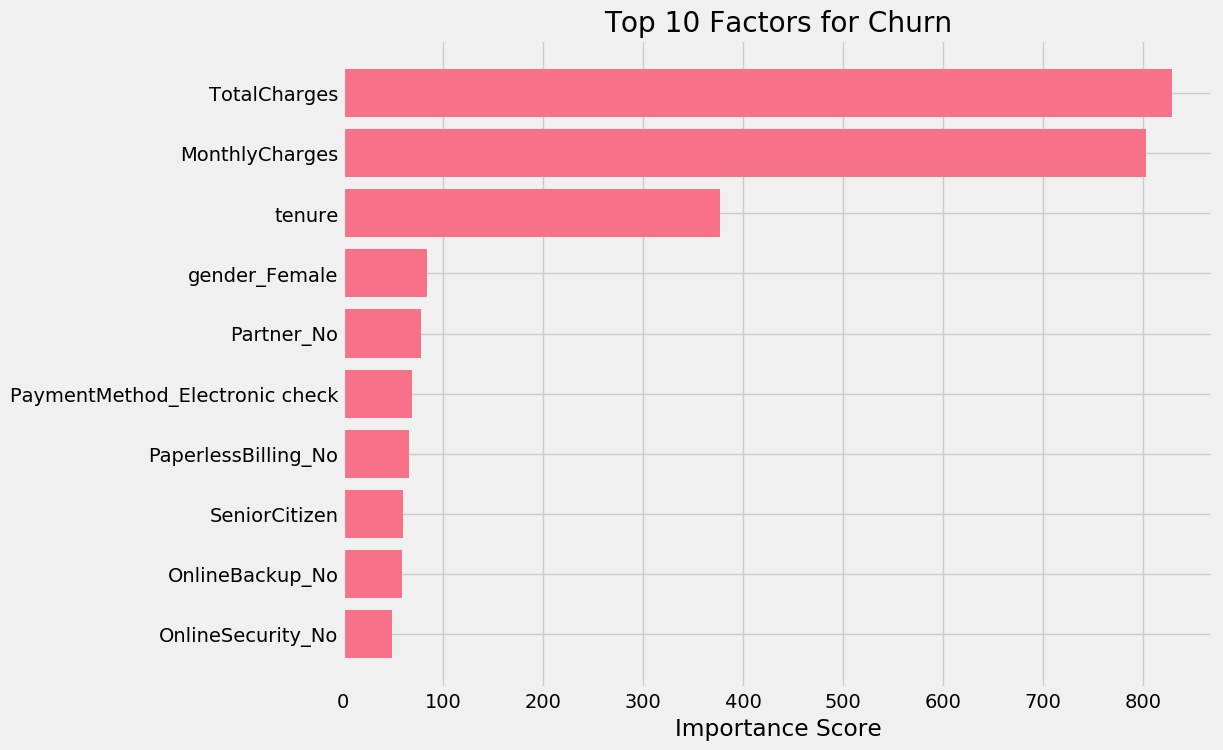

In [30]:
import matplotlib.pyplot as plt

# Get feature importance
importance = model.get_booster().get_score(importance_type='weight')
# Sort and plot
importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(10, 8))
plt.barh(list(importance.keys())[:10], list(importance.values())[:10])
plt.xlabel("Importance Score")
plt.title("Top 10 Factors for Churn")
plt.gca().invert_yaxis()
plt.show()